In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import math

# Charger le CSV
df1 = pd.read_csv("client/core1/latences.csv", sep="\t", header=None, names=["latence", "code"])
df5 = pd.read_csv("client/core5/latences.csv", sep="\t", header=None, names=["latence", "code"])
df10 = pd.read_csv("client/core10/latences.csv", sep="\t", header=None, names=["latence", "code"])
dfall = pd.read_csv("client/coreall/latences.csv", sep="\t", header=None, names=["latence", "code"])
dfswitch = pd.read_csv("client/coreswitch/latences.csv", sep="\t", header=None, names=["latence", "code"])

dd1 = pd.read_csv("client/core1/debits.csv", sep="\s+", header=None, names=["req_per_sec", "timestamp"])
dd5 = pd.read_csv("client/core5/debits.csv", sep="\s+", header=None, names=["req_per_sec", "timestamp"])
dd10 = pd.read_csv("client/core10/debits.csv", sep="\s+", header=None, names=["req_per_sec", "timestamp"])
ddall = pd.read_csv("client/coreall/debits.csv", sep="\s+", header=None, names=["req_per_sec", "timestamp"])
ddswitch = pd.read_csv("client/coreswitch/debits.csv", sep="\s+", header=None, names=["req_per_sec", "timestamp"])

dd1["t_rel"] = (dd1["timestamp"] - dd1["timestamp"].min()) + 1
dd5["t_rel"] = (dd5["timestamp"] - dd5["timestamp"].min()) + 1
dd10["t_rel"] = (dd10["timestamp"] - dd10["timestamp"].min()) + 1
ddall["t_rel"] = (ddall["timestamp"] - ddall["timestamp"].min()) + 1
ddswitch["t_rel"] = (ddswitch["timestamp"] - ddswitch["timestamp"].min()) + 1

###Server
dfs1 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core1/cpu_freq_log.csv",  parse_dates=["timestamp"])
dfs5 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core5/cpu_freq_log.csv",  parse_dates=["timestamp"])
dfs10 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core10/cpu_freq_log.csv",  parse_dates=["timestamp"])
dfsall = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/coreall/cpu_freq_log.csv", parse_dates=["timestamp"])
dfsswitch = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/coreswitch/cpu_freq_log.csv",  parse_dates=["timestamp"])
dfs = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/cpu_freq_log.csv",  parse_dates=["timestamp"])


dfw1 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core1/powerstat.csv", sep=r"\s+",skiprows=3)

dfw2 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core5/powerstat.csv", sep=r"\s+",skiprows=3)

dfw3 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/core10/powerstat.csv", sep=r"\s+",skiprows=3)

dfw4 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/coreall/powerstat.csv", sep=r"\s+",skiprows=3)

dfw5 = pd.read_csv("data/with_cpupower/nodejs/with_powerstat/server/coreswitch/powerstat.csv", sep=r"\s+",skiprows=3)




FileNotFoundError: [Errno 2] No such file or directory: 'client/core1/latences.csv'

# Latence ms

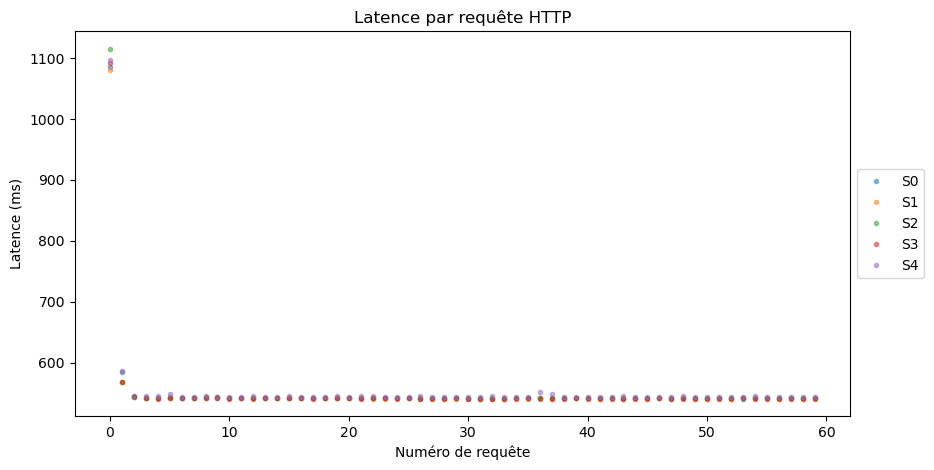

In [17]:
plt.figure(figsize=(10,5))
plt.plot(dfall.index, dfall["latence"]*1000, marker=".", linestyle="none",label='S0',alpha=0.5)
plt.plot(df1.index, df1["latence"]*1000, marker=".", linestyle="none",label='S1', alpha=0.5)  # en ms
plt.plot(df5.index, df5["latence"]*1000, marker=".", linestyle="none",label='S2',alpha=0.5)
plt.plot(df10.index, df10["latence"]*1000, marker=".", linestyle="none",label='S3',alpha=0.5)
plt.plot(dfswitch.index, dfswitch["latence"]*1000, marker=".", linestyle="none",label='S4',alpha=0.5)
#plt.ylim([0, 600])
plt.xlabel("Numéro de requête")
plt.ylabel("Latence (ms)")
plt.title("Latence par requête HTTP")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.show()

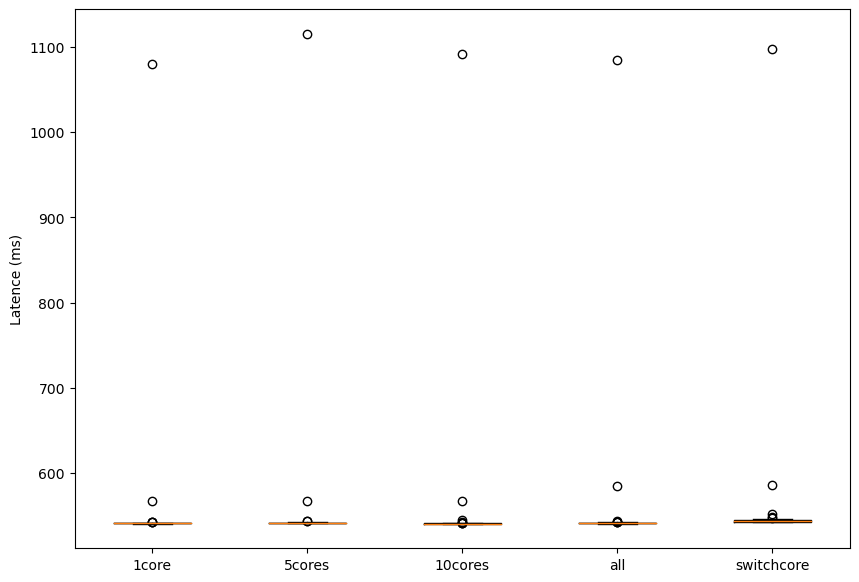

In [3]:
dfb = [df1['latence']*1000,df5['latence']*1000,df10['latence']*1000,dfall['latence']*1000,dfswitch['latence']*1000]
fig = plt.figure(figsize =(10, 7))
#plt.ylim([0, 60])
plt.ylabel("Latence (ms)")
plt.boxplot(dfb,labels=['1core', '5cores', '10cores','all','switchcore'])
plt.show()

In [4]:
print((df1['latence']*1000).quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",(df1['latence']*1000).mean(),"\n")

print((df5['latence']*1000).quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",(df5['latence']*1000).mean(),"\n")

print((df10['latence']*1000).quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",(df10['latence']*1000).mean(),"\n")

print((dfall['latence']*1000).quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",(dfall['latence']*1000).mean(),"\n")

print((dfswitch['latence']*1000).quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",(dfswitch['latence']*1000).mean(),"\n")

0.25    540.87500
0.50    541.09500
0.75    541.37200
0.95    542.82325
0.99    777.37357
Name: latence, dtype: float64
Moyenne:  550.5831166666667 

0.25    541.27650
0.50    541.36950
0.75    541.69725
0.95    543.48870
0.99    792.10733
Name: latence, dtype: float64
Moyenne:  551.5255 

0.25    540.73650
0.50    540.82250
0.75    541.00800
0.95    542.49245
0.99    782.24569
Name: latence, dtype: float64
Moyenne:  550.6011166666666 

0.25    541.05000
0.50    541.30700
0.75    541.63700
0.95    542.78595
0.99    790.15330
Name: latence, dtype: float64
Moyenne:  551.1902000000001 

0.25    543.02150
0.50    543.47200
0.75    544.60475
0.95    548.42225
0.99    795.67235
Name: latence, dtype: float64
Moyenne:  553.8519 



In [5]:
valeurs = [0.000151, 0.000137, 0.000156, 0.000152, 0.000154]

# Moyenne
moyenne = np.mean(valeurs)

# Écart-type (échantillon : ddof=1)
ecart_type = np.std(valeurs, ddof=1)

# Coefficient de variation (%)
cv = (ecart_type / moyenne) * 100

print("Moyenne :", moyenne)
print("Écart-type :", ecart_type)
print("Coefficient de variation (%) :", cv)

Moyenne : 0.00015000000000000001
Écart-type : 7.516648189186457e-06
Coefficient de variation (%) : 5.011098792790971


# Débit req/s

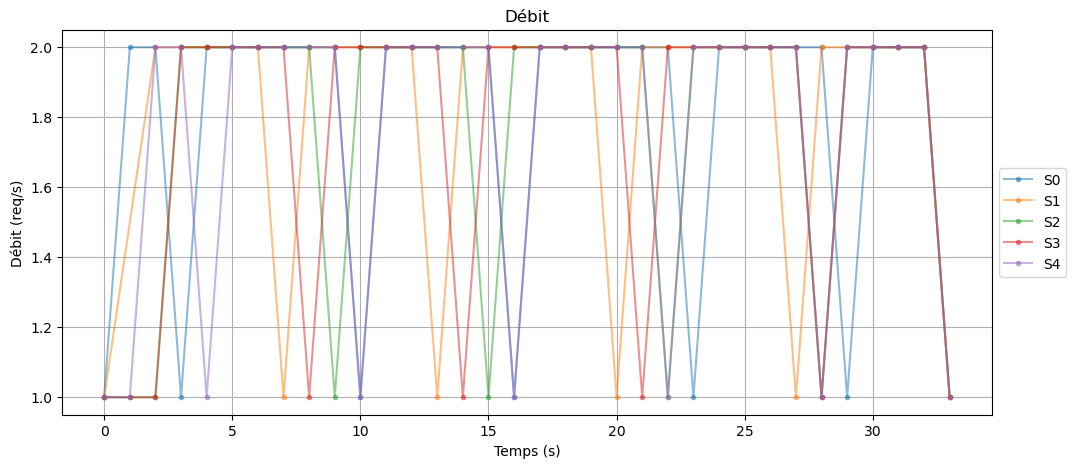

In [6]:
plt.figure(figsize=(12,5))
plt.plot(ddall["t_rel"]-1, ddall["req_per_sec"], marker=".",label='S0', alpha=0.5)
plt.plot(dd1["t_rel"]-1, dd1["req_per_sec"], marker=".", label='S1',alpha=0.5)
plt.plot(dd5["t_rel"]-1, dd5["req_per_sec"], marker=".",label='S2', alpha=0.5)
plt.plot(dd10["t_rel"]-1, dd10["req_per_sec"], marker=".",label='S3',alpha=0.5)
plt.plot(ddswitch["t_rel"]-1, ddswitch["req_per_sec"], marker=".",label='S4',alpha=0.5)
#plt.ylim([0, 5500])
plt.xlabel("Temps (s)")
plt.ylabel("Débit (req/s)")
plt.title("Débit")
plt.grid(True)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.show()


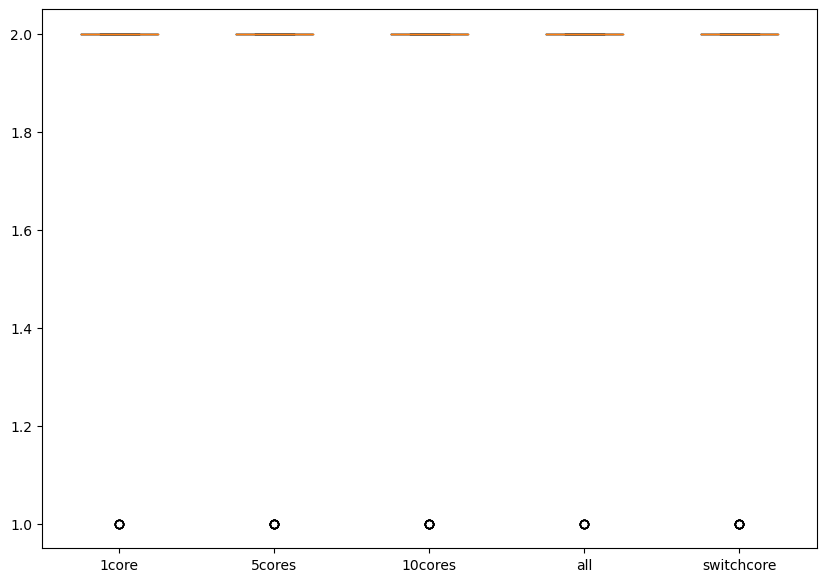

In [7]:
ddb = [dd1['req_per_sec'],dd5['req_per_sec'],dd10['req_per_sec'],ddall['req_per_sec'],ddswitch['req_per_sec']]
fig = plt.figure(figsize =(10, 7))
#plt.ylim([0, 60])
plt.boxplot(ddb,labels=['1core', '5cores', '10cores','all','switchcore'])
plt.show()

In [8]:
print(dd1['req_per_sec'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",dd1['req_per_sec'].mean(),"\n")

print(dd5['req_per_sec'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",dd5['req_per_sec'].mean(),"\n")

print(dd10['req_per_sec'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",dd10['req_per_sec'].mean(),"\n")

print(ddall['req_per_sec'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",ddall['req_per_sec'].mean(),"\n")

print(ddswitch['req_per_sec'].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Moyenne: ",ddswitch['req_per_sec'].mean(),"\n")

0.25    2.0
0.50    2.0
0.75    2.0
0.95    2.0
0.99    2.0
Name: req_per_sec, dtype: float64
Moyenne:  1.8181818181818181 

0.25    2.0
0.50    2.0
0.75    2.0
0.95    2.0
0.99    2.0
Name: req_per_sec, dtype: float64
Moyenne:  1.7647058823529411 

0.25    2.0
0.50    2.0
0.75    2.0
0.95    2.0
0.99    2.0
Name: req_per_sec, dtype: float64
Moyenne:  1.7647058823529411 

0.25    2.0
0.50    2.0
0.75    2.0
0.95    2.0
0.99    2.0
Name: req_per_sec, dtype: float64
Moyenne:  1.8181818181818181 

0.25    2.0
0.50    2.0
0.75    2.0
0.95    2.0
0.99    2.0
Name: req_per_sec, dtype: float64
Moyenne:  1.7647058823529411 



In [9]:
valeurs = [3725.82, 4098.92, 3602.95, 4011.28, 3376.62]

# Moyenne
moyenne = np.mean(valeurs)

# Écart-type (échantillon : ddof=1)
ecart_type = np.std(valeurs, ddof=1)

# Coefficient de variation (%)
cv = (ecart_type / moyenne) * 100

print("Moyenne :", moyenne)
print("Écart-type :", ecart_type)
print("Coefficient de variation (%) :", cv)

Moyenne : 3763.118
Écart-type : 296.1304587846378
Coefficient de variation (%) : 7.869284428089627


# Fréquence

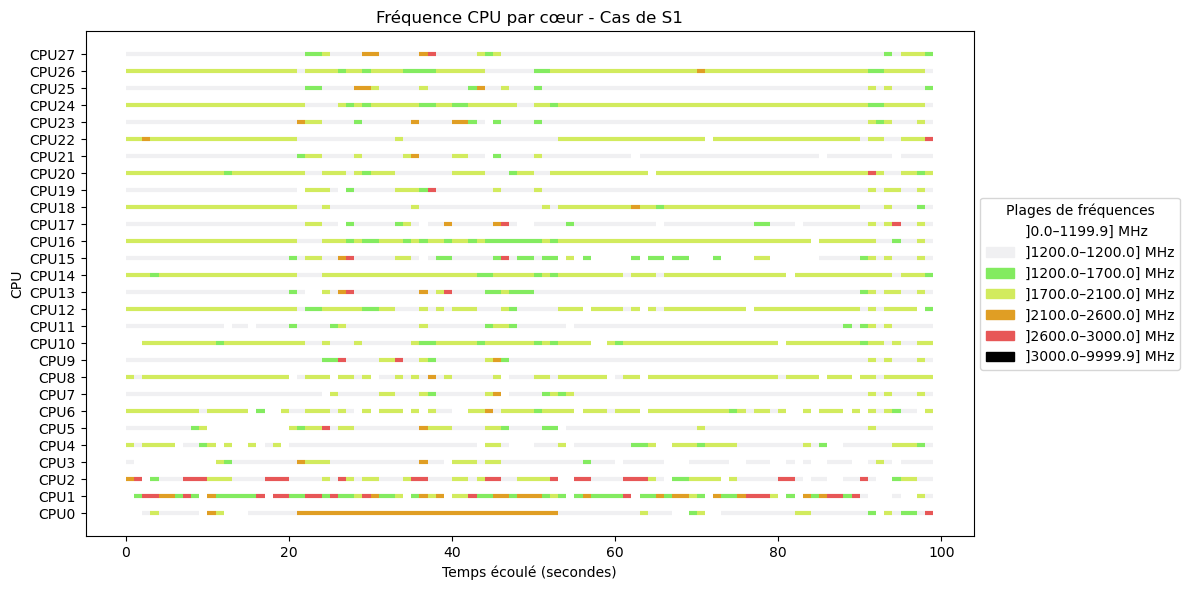

In [10]:
t1 = dfs1["timestamp"].iloc[0]
dfs1["t_seconds"] = (dfs1["timestamp"] - t1).dt.total_seconds()

seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "black")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfs1.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfs1)):
        t0, t1 = dfs1["t_seconds"].iloc[i-1], dfs1["t_seconds"].iloc[i]
        f = dfs1[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de S1")
plt.tight_layout()
plt.show()

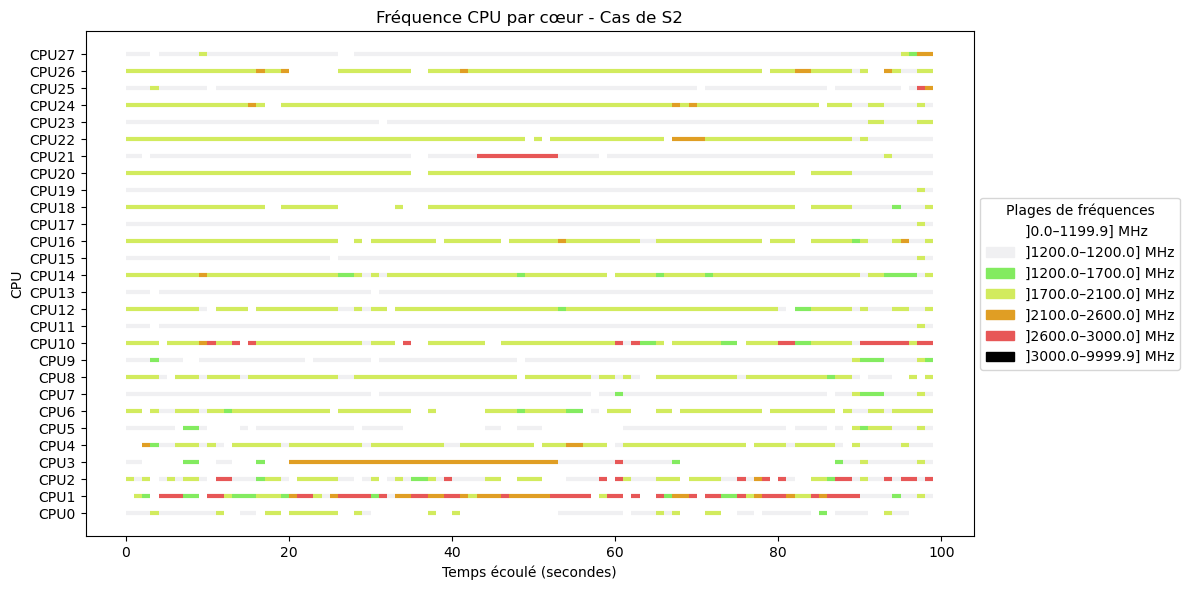

In [11]:
t5 = dfs5["timestamp"].iloc[0]
dfs5["t_seconds"] = (dfs5["timestamp"] - t5).dt.total_seconds()

seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "black")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfs5.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfs5)):
        t0, t1 = dfs5["t_seconds"].iloc[i-1], dfs5["t_seconds"].iloc[i]
        f = dfs5[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de S2")
plt.tight_layout()
plt.show()

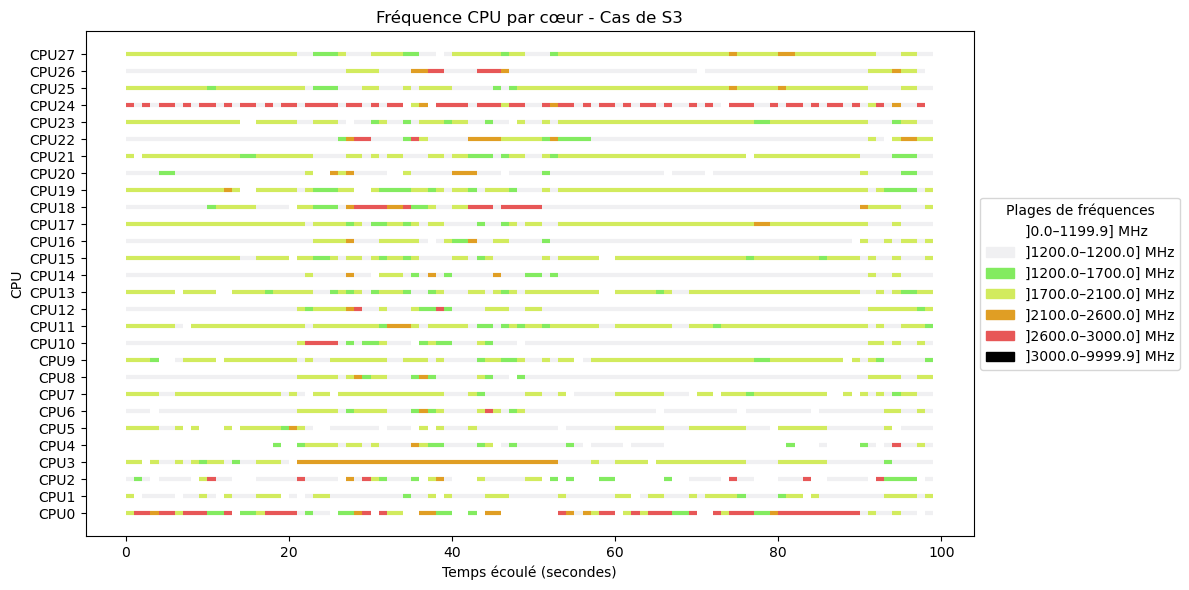

In [12]:
t10 = dfs10["timestamp"].iloc[0]
dfs10["t_seconds"] = (dfs10["timestamp"] - t10).dt.total_seconds()

seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "black")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfs10.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfs10)):
        t0, t1 = dfs10["t_seconds"].iloc[i-1], dfs10["t_seconds"].iloc[i]
        f = dfs10[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de S3")
plt.tight_layout()
plt.show()

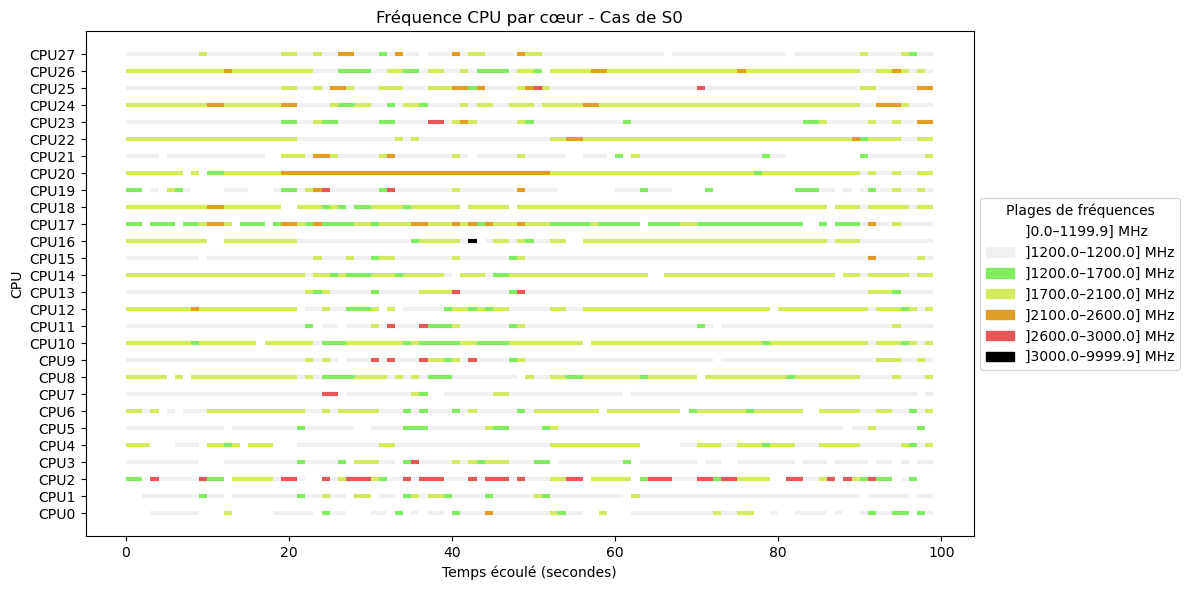

In [13]:
ta = dfsall["timestamp"].iloc[0]
dfsall["t_seconds"] = (dfsall["timestamp"] - ta).dt.total_seconds()

seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "black")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfsall.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfsall)):
        t0, t1 = dfsall["t_seconds"].iloc[i-1], dfsall["t_seconds"].iloc[i]
        f = dfsall[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de S0")
plt.tight_layout()
plt.show()

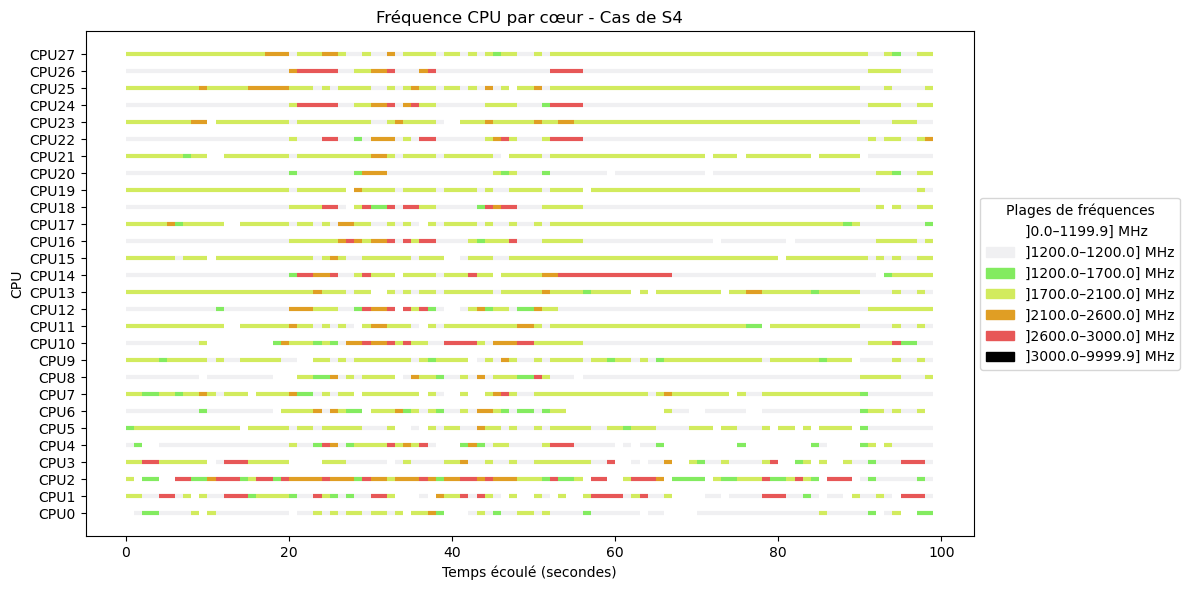

In [14]:
ts = dfsswitch["timestamp"].iloc[0]
dfsswitch["t_seconds"] = (dfsswitch["timestamp"] - ts).dt.total_seconds()

seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "black")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfsswitch.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfsswitch)):
        t0, t1 = dfsswitch["t_seconds"].iloc[i-1], dfsswitch["t_seconds"].iloc[i]
        f = dfsswitch[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de S4")
plt.tight_layout()
plt.show()

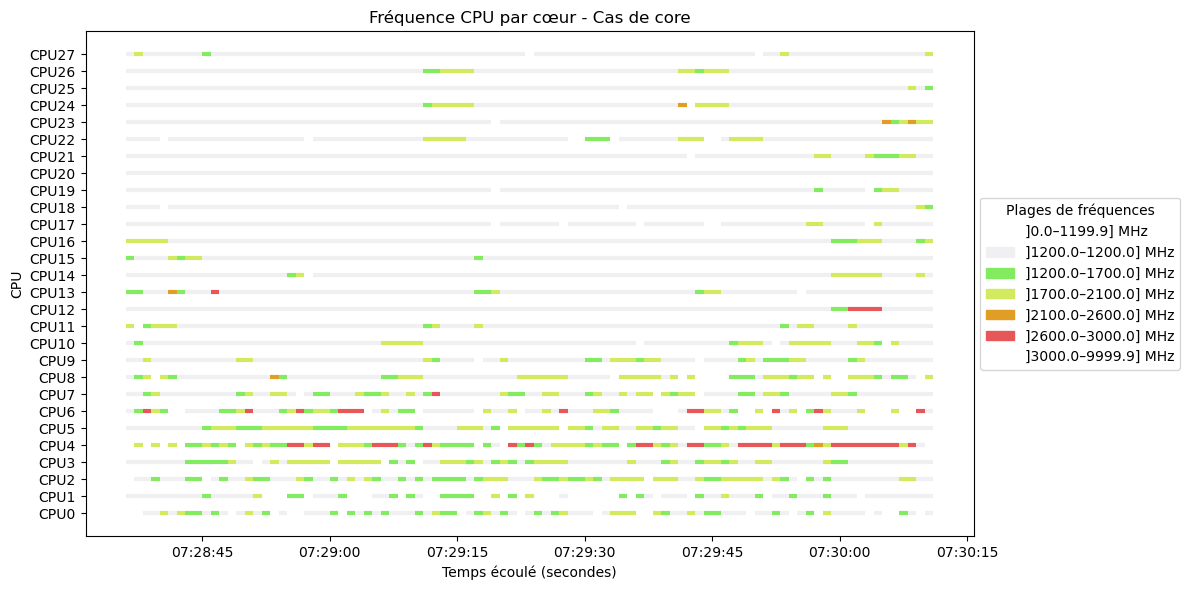

In [15]:
seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "white")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfs.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfs)):
        t0, t1 = dfs["timestamp"].iloc[i-1], dfs["timestamp"].iloc[i]
        f = dfs[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.set_xlabel("Temps écoulé (secondes)")

plt.title("Fréquence CPU par cœur - Cas de core")
plt.tight_layout()
plt.show()

NameError: name 'dfse1' is not defined

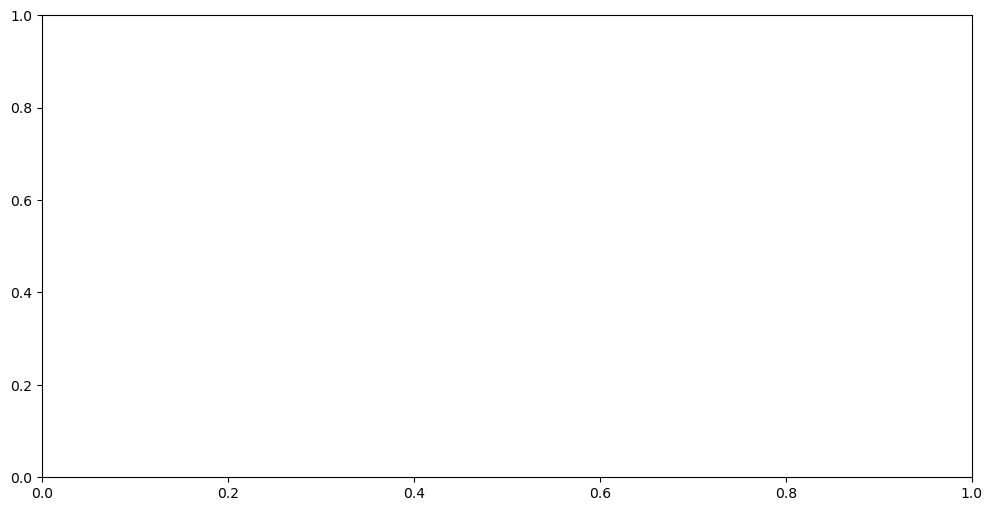

In [16]:
seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "white")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfse1.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfse1)):
        t0, t1 = dfse1["timestamp"].iloc[i-1], dfse1["timestamp"].iloc[i]
        f = dfse1[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.title("Fréquence CPU par cœur - Cas de core")
plt.tight_layout()
plt.show()

In [ ]:
seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "white")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfse2.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfse2)):
        t0, t1 = dfse2["timestamp"].iloc[i-1], dfse2["timestamp"].iloc[i]
        f = dfse2[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.title("Fréquence CPU par cœur - Cas de core")
plt.tight_layout()
plt.show()

In [ ]:
seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "white")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfse3.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfse3)):
        t0, t1 = dfse3["timestamp"].iloc[i-1], dfse3["timestamp"].iloc[i]
        f = dfse3[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.title("Fréquence CPU par cœur - Cas de core")
plt.tight_layout()
plt.show()

In [ ]:
seuils = [(0, 1199999, "white"),  
          (1200000, 1200000, "#f0f0f2"), # basse fréquence
          (1200001, 1700000, "#83eb60"),
          (1700001, 2100000, "#d2eb5e"),# moyenne
          (2100001, 2600000, "#e09e24"),
         (2600001, 3000000, "#e75757"),
         (3000001, 9999999, "white")]

fig, ax = plt.subplots(figsize=(12, 6))

cpus_to_plot = dfse4.columns[1:29] 

# Pour chaque CPU (sauf timestamp)
for col in cpus_to_plot:
    y = int(col.replace("CPU", ""))  # numéro du CPU
    for i in range(1, len(dfse4)):
        t0, t1 = dfse4["timestamp"].iloc[i-1], dfse4["timestamp"].iloc[i]
        f = dfse4[col].iloc[i]
        
        # Choisir la couleur selon le seuil
        color = "black"
        for bas, haut, c in seuils:
            if bas <= f <= haut:
                color = c
                break
        
        # Tracer un segment horizontal entre t0 et t1
        ax.hlines(y, t0, t1, colors=color, linewidth=3)

        patches = []
for bas, haut, c in seuils:
    bas_mhz = math.floor((bas/1000) * 10) / 10
    haut_mhz = math.floor((haut/1000) * 10) / 10
    label = f"]{bas_mhz:.1f}–{haut_mhz:.1f}] MHz"
    patches.append(mpatches.Patch(color=c, label=label))

ax.legend(handles=patches, title="Plages de fréquences",
          loc="center left", bbox_to_anchor=(1, 0.5))  

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# Mise en forme
ax.set_xlabel("Temps")
ax.set_ylabel("CPU")
ax.set_yticks(range(28))
ax.set_yticklabels(cpus_to_plot)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

plt.title("Fréquence CPU par cœur - Cas de core")
plt.tight_layout()
plt.show()

In [ ]:
dfw1["Watts"] = pd.to_numeric(dfw1["Watts"], errors="coerce")
dfw1 = dfw1.dropna(subset=["Watts"])

dfw2["Watts"] = pd.to_numeric(dfw2["Watts"], errors="coerce")
dfw2 = dfw2.dropna(subset=["Watts"])

dfw3["Watts"] = pd.to_numeric(dfw3["Watts"], errors="coerce")
dfw3 = dfw3.dropna(subset=["Watts"])

dfw4["Watts"] = pd.to_numeric(dfw4["Watts"], errors="coerce")
dfw4 = dfw4.dropna(subset=["Watts"])

dfw5["Watts"] = pd.to_numeric(dfw5["Watts"], errors="coerce")
dfw5 = dfw5.dropna(subset=["Watts"])

dfw1["Watts"]

dfw1 = dfw1.iloc[:-5]
dfw2 = dfw2.iloc[:-5]
dfw3 = dfw3.iloc[:-5]
dfw4 = dfw4.iloc[:-5]
dfw5 = dfw5.iloc[:-5]
dfw1["Watts"]

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(dfw4.index / 2,dfw4["Watts"], label='S0')
plt.plot(dfw1.index / 2,dfw1["Watts"], label='S1')
plt.plot(dfw2.index / 2,dfw2["Watts"], label='S2')
plt.plot(dfw3.index / 2,dfw3["Watts"], label='S3')
plt.plot(dfw5.index / 2,dfw5["Watts"], label='S4')
#plt.ylim([120, 150])
#plt.plot(df_sample['PkgWatt'], label='PkgWatt')
plt.xlabel("Temps (s)")
plt.ylabel("Energie (J)")
plt.title("Energie consommée en fonction de l'affinité CPU")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.grid(True)
plt.show()

In [ ]:
dfs = [dfw1["Watts"],dfw2["Watts"],dfw3["Watts"],dfw4["Watts"],dfw5["Watts"]]
fig = plt.figure(figsize =(10, 7))

plt.boxplot(dfs,labels=['1 coeur', '5 coeurs', '10 coeurs','tous les coeurs','coeurs switchés'])
plt.show()


In [ ]:
print(dfw1["Watts"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Min: ",dfw1["Watts"].min())
print("Max: ",dfw1["Watts"].max())
print("Moyenne: ",dfw1["Watts"].mean(),"\n")

print(dfw2["Watts"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Min: ",dfw2["Watts"].min())
print("Max: ",dfw2["Watts"].max())
print("Moyenne: ",dfw2["Watts"].mean(),"\n")

print(dfw3["Watts"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Min: ",dfw3["Watts"].min())
print("Max: ",dfw3["Watts"].max())
print("Moyenne: ",dfw3["Watts"].mean(),"\n")

print(dfw4["Watts"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Min: ",dfw4["Watts"].min())
print("Max: ",dfw4["Watts"].max())
print("Moyenne: ",dfw4["Watts"].mean(),"\n")

print(dfw5["Watts"].quantile([0.25, 0.5, 0.75, 0.95, 0.99]))
print("Min: ",dfw5["Watts"].min())
print("Max: ",dfw5["Watts"].max())
print("Moyenne: ",dfw5["Watts"].mean(),"\n")

In [ ]:
total_watts = dfw4["Watts"].sum()
total1_watts = dfw1["Watts"].sum()
total2_watts = dfw2["Watts"].sum()
total3_watts = dfw3["Watts"].sum()
total4_watts = dfw5["Watts"].sum()
print(total_watts)
print(total1_watts)
print(total2_watts)
print(total3_watts)
print(total4_watts)

In [ ]:
print((((85.8*10000000)/60)*100000*99)/3600000)
print((((85.8*50000000)/60)*100000*99)/3600000)
print((((85.8*100000000)/60)*100000*99)/3600000)
print((((85.8*200000000)/60)*100000*99)/3600000)
print((((85.8*400000000)/60)*100000*99)/3600000)
print((((85.8*500000000)/60)*100000*99)/3600000)

In [ ]:
print((((85.8*10000)/60)*100000)/(3600000*12))
print((((85.8*50000)/60)*100000)/(3600000*12))
print((((85.8*100000)/60)*100000)/(3600000*12))
print((((85.8*200000)/60)*100000)/(3600000*12))
print((((85.8*400000)/60)*100000)/(3600000*12))
print((((85.8*500000)/60)*100000)/(3600000*12))

In [ ]:
Eall = dfw4["Watts"].sum()
E1 = dfw1["Watts"].sum()
E5 = dfw2["Watts"].sum()
E10 = dfw3["Watts"].sum()
Esw = dfw5["Watts"].sum()

E_ref = Eall
gains = {
    "S1":  (E_ref - E1),
    "S2": (E_ref - E5) ,
    "S3": (E_ref - E10) ,
    "S0": 0,
    "S4": (E_ref - Esw)
}

In [ ]:
# Trier par gain décroissant
sorted_gains = sorted(
    gains.items(),
    key=lambda x: x[1],
    reverse=True
)

labels = [x[0] for x in sorted_gains]
values = [x[1] for x in sorted_gains]

# Création du dégradé de couleurs
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(values))
)

# Plot
plt.figure(figsize=(10,6))

bars = plt.bar(labels, values, color=colors)

# Ligne zéro
plt.axhline(0, linestyle="--", alpha=0.6)

# Valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom" if height >= 0 else "top"
    )

plt.xlabel("Scénario")
plt.ylabel("Gain énergétique (J)")
plt.title("Gain énergétique par scénario")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
E_ref = float(Eall)

# Gains (J, %)
gains = {
    "S1":  (E_ref - E1, (E_ref - E1)/E_ref*100),
    "S2": (E_ref - E5, (E_ref - E5)/E_ref*100),
    "S3":(E_ref - E10,(E_ref - E10)/E_ref*100),
    "S0":(0.0, 0.0),
    "S4": (E_ref - Esw,(E_ref - Esw)/E_ref*100)
}
# Tri par gain en J
sorted_gains = sorted(
    gains.items(),
    key=lambda x: x[1][0],
    reverse=True
)

labels = [x[0] for x in sorted_gains]
joules = [x[1][0] for x in sorted_gains]
percents = [x[1][1] for x in sorted_gains]

# Dégradé
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(joules))
)

# Plot
plt.figure(figsize=(11,6))

bars = plt.bar(labels, joules, color=colors)

plt.axhline(0, linestyle="--", alpha=0.6)

# Annotations
for bar, j, p in zip(bars, joules, percents):

    text = f"{j:+.2f} J\n({p:+.2f} %)"

    plt.text(
        bar.get_x() + bar.get_width()/2,
        j,
        text,
        ha="center",
        va="bottom" if j >= 0 else "top",
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel("Scénario")
plt.ylabel("Gain énergétique (J)")
plt.title("Gain énergétique par scénario")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.margins(x=0.1, y=0.2)
plt.show()